# 리포트 8-4 — 마이크로도플러: 무엇을 잴 수 있나

> **8 권은 네 편이다** — [08_1 시나리오](08_1_scene.ipynb) · [08_2 세 엔진과 거리](08_2_engines.ipynb) · [08_3 무늬를 정하는 것](08_3_pattern.ipynb) · [08_4 무엇을 잴 수 있나](08_4_sampling.ipynb)

> **두 가지가 잴 수 있는 것을 제한한다 — 광선 비용과 조명원 반복률.** 앞의 것은 우리가 감당하는 문제이고, 뒤의 것은 우리가 못 정하는 조건이다.

⭐ 숫자는 전부 계산 결과 JSON(원장)에서 주입된다 — 원장이 다시 계산되면 `python src/make_report08_microdoppler.py` 한 번으로 본문 숫자가 따라 바뀐다.


## 거리 — 벽인가 예산인가

**시나리오** — 진짜 모노스태틱(TX=RX, 기선 0), 배 쪽(방위 0·앙각 −15), 3.5 GHz CW. 표적을 3 → 10 → 20 → 40 m 로 물리며 자세당 발견 경로 수를 셌다.

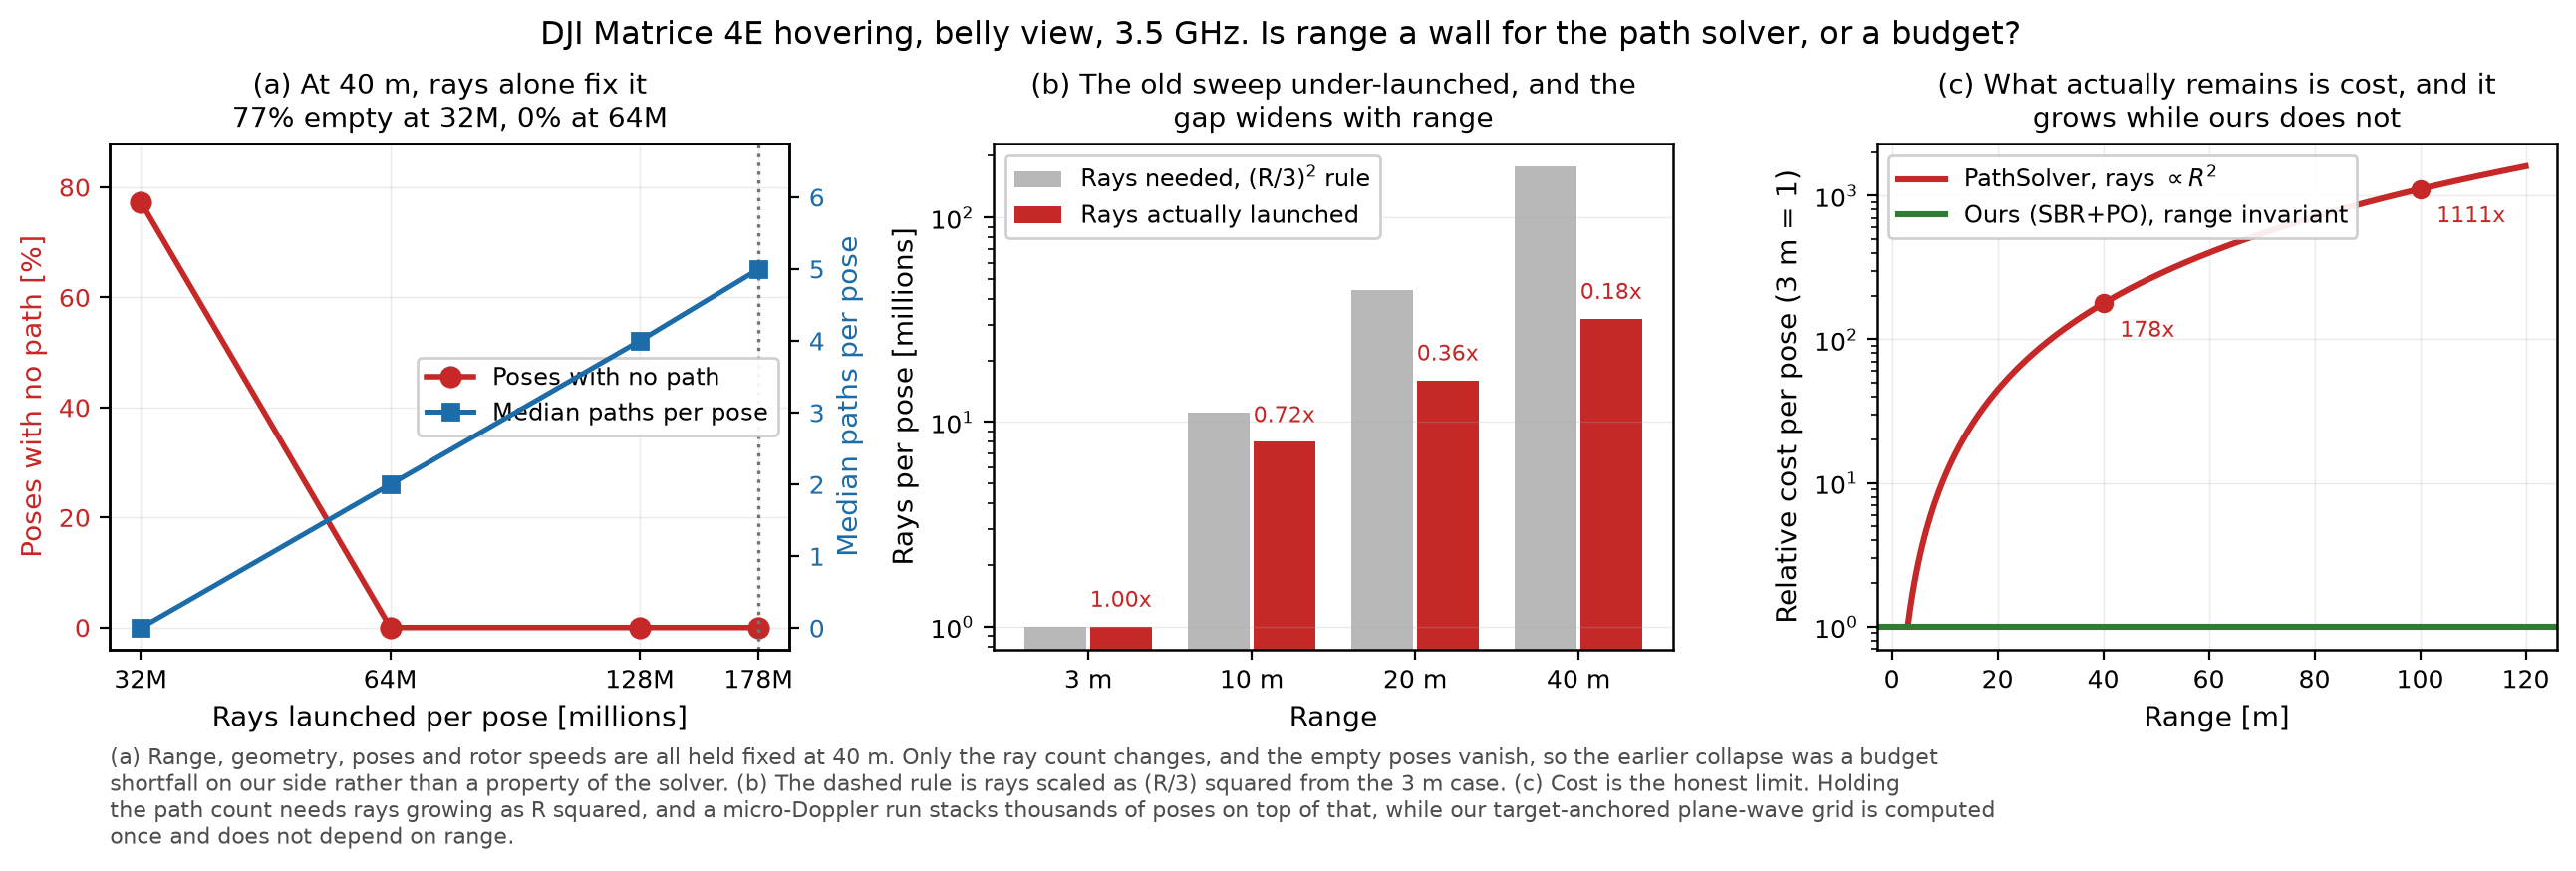

⚠ **정직 정정** — 처음에 «40 m 에서 자세의 78 % 가 경로 0 이니 PathSolver 의 구조적 한계» 라고 적었다. **그것은 틀렸다.** 그 스윕의 광선 예산이 규칙값 (R/3)² 의 1.00 / 0.72 / 0.36 / **0.18배**였기 때문이다.

⭐ 그래서 **결판 시험**을 했다 — 40 m 를 고정하고 자세·기하·회전수를 그대로 둔 채 **광선만** 사다리로 올렸다.

| 40 m 광선 | 경로 중앙 | 경로 평균 | 빈 자세 |
|---|---|---|---|
| 32M | 0 | 0.34 | 77.3% |
| 64M | 2 | 1.66 | 0.0% |
| 128M | 4 | 3.69 | 0.0% |
| 178M | 5 | 5.38 | 0.0% |

⭐ **판정 — 예산 부족이었다 — 광선을 규칙대로 쏘니 빈 자세가 사라진다** 규칙값의 절반도 안 되는 지점에서 이미 빈 자세가 사라진다.

⭐ **그러면 무엇이 남는가 — 비용이다.** 거리가 두 배면 광선을 네 배 부어야 같은 경로 수를 얻는다. 40 m 규칙값이 178M 이면 100 m 에서는 그 여섯 배가 필요하고, 자세를 수천 개 쌓는 마이크로도플러에서는 그 곱이 감당 밖으로 간다. 반면 우리 SBR+PO 는 광선 격자를 **표적에 앵커**(λ/12 간격)한 평면파 조명이라, 원거리장 경계(8.3 m) 밖에서는 무늬가 거리에 **불변**이고 수신 레벨만 1/R² 로 내려간다 — 즉 **한 번 계산하면 거리에 무관**하다.

⭐ 그러므로 원거리 마이크로도플러를 SBR+PO 가 맡는 이유는 «PathSolver 가 못 해서» 가 아니라 **«비용이 거리와 함께 터지기 때문»** 이다.


## 같은 채널에 5G 파형을 실제로 태우면

**시나리오** — 채널은 08_3 의 2 초 호버링 h(t) **그대로**다(같은 원장). 바꾼 것은 파형뿐이다: 5G NR 형 OFDM — SCS 30 kHz(n78) · 유효 부반송파 1,024개 · 심볼마다 무작위 QPSK · 심볼율 28k sym/s. 수신은 기지 심볼 나눗셈으로 심볼마다 채널 ĥ 을 꺼낸다. 네 팔은 **«채널을 얼마나 자주 읽나»(반복률)만** 다르다.

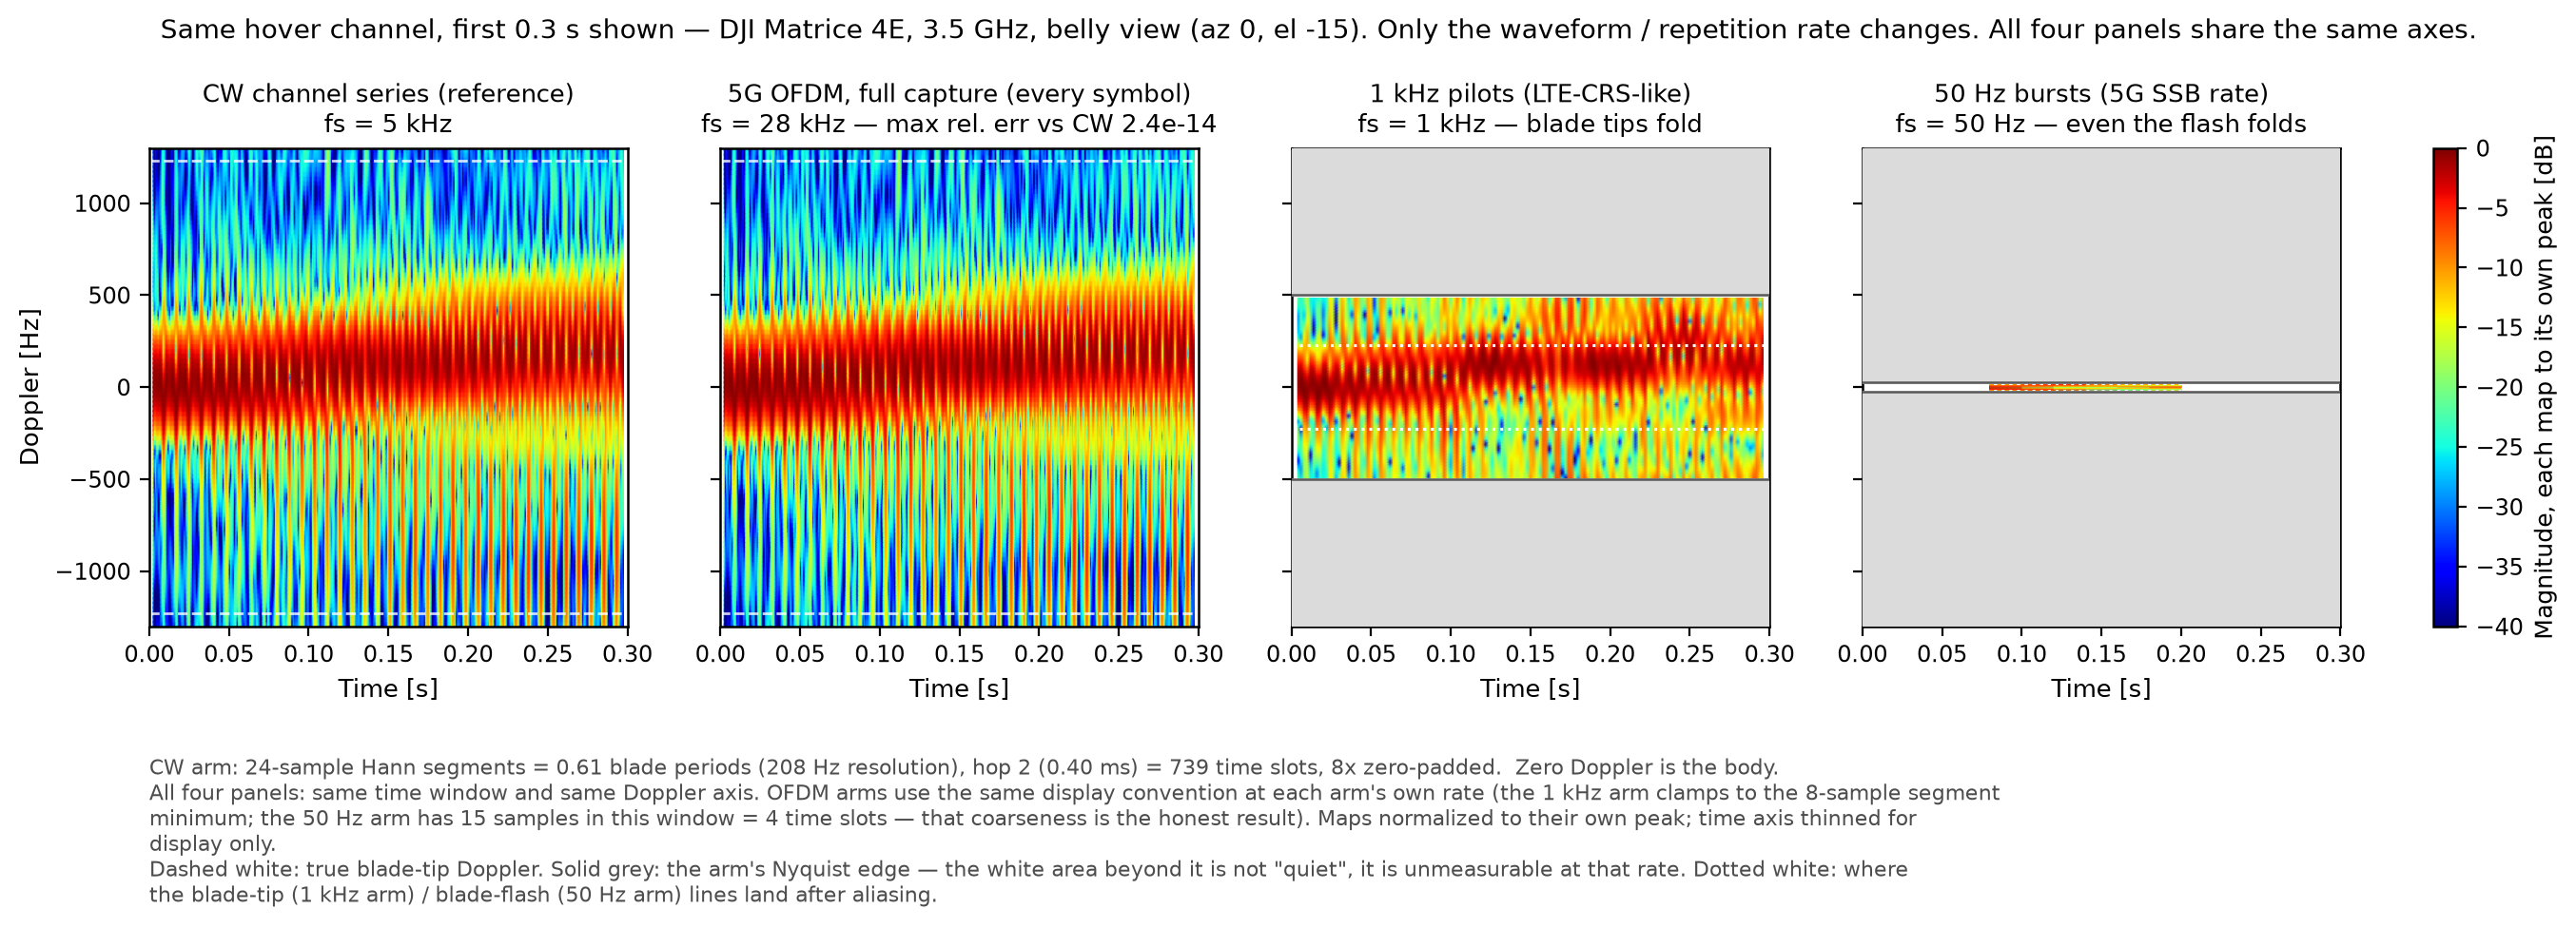

| 팔 | 표본율 | 나이퀴스트 | 날개끝 ±1229 Hz | 플래시 127 Hz |
|---|---|---|---|---|
| CW channel series (reference) | 5000 Hz | ±2500 Hz | 보임 | 보임 |
| 5G OFDM, full capture (every symbol) | 28000 Hz | ±14000 Hz | 보임 | 보임 |
| 1 kHz pilots (LTE-CRS-like) | 1000 Hz | ±500 Hz | ⚠접힘 | 보임 |
| 50 Hz bursts (5G SSB rate) | 50 Hz | ±25 Hz | ⚠접힘 | ⚠접힘 |

⭐ 이것이 **5G 이중고**의 그림판이다 — 패시브가 기댈 상시 신호 기준으로, LTE CRS 급 1 kHz 는 날개끝이 나이퀴스트 500 Hz 안으로 **접혀** 들어오고, 5G SSB 급 50 Hz 는 **플래시선마저** 접힌다. 관측 창이 ±25 Hz, 속도로는 ±1.07 m/s 뿐인데 날개끝은 초당 52.7 m 로 움직인다.

⭐ **네 패널은 축이 완전히 같다.** 그래서 낮은 반복률의 대가가 **빈 자리**로 보인다 — 회색으로 덮은 영역은 «조용함» 이 아니라 **그 표본율로는 측정 자체가 불가능한 영역**이다.

⚠ **이 수치가 무엇을 재는지 정확히 적는다.** «풀캡처 ≡ CW» 의 2.4e-14 는 **OFDM 수신 사슬이 채널을 정확히 되돌려주는가**를 잰 것이다. 평탄-채널 근사 아래에서 그 사슬은 항등식이므로 이 값이 작은 것은 **구현이 맞다는 확인**이지, 5G 와 CW 가 같은 물리를 본다는 **독립 검증이 아니다**. ⭐이 그림의 진짜 내용은 오른쪽 두 팔, 즉 **반복률**에 있다.

⚠ 정직 한계 둘 — 5 kHz 채널열을 28 kHz 로 다상 보간했고(대역제한 가드 2.1e-03), 심볼 안에서 채널이 도는 ICI 를 1차 근사로 재면 바닥이 -17.8 dB 인데 채널 모형에는 넣지 않았다.


## 부록 — 그림별 데이터 이력

그림마다 딛고 선 원장과 그 시점이 다르다. ⭐**원장의 PRF 가 다르면 시간 분해능도 다르다** — 그래서 그림마다 선명도가 갈릴 수 있다.

| 그림 | 편 | 원장 | 생성 | PRF |
|---|---|---|---|---|
| 애니메이션 · f0 · f0c | 08_1 | 렌더(수치 없음) | 2026-08-10 | — |
| f12 · f8 · f2 | 08_2 | `report07_three_engines.json` | 2026-08-10 06:23 | 19700 Hz |
| f1 · f4 · f3 | 08_3 | `report15b_microdoppler.json` | 2026-08-10 04:41 | 5000 Hz |
| f7 | 08_3 | `report07_hover_long.json` | 2026-08-07 13:29 | 5000 Hz |
| f11 | 08_3 | `report07_hover_long_outdoor.json` | 2026-08-10 05:07 | 5000 Hz |
| f13 | 08_3 | `rotor_log_traces.json` (공개 비행로그) | 2026-08-10 | 로그 원본 |
| f9 | 08_4 | `report07_ray_budget_test.json` + `report07_sionna_ranges.json` | 2026-08-10 04:31 | 5000 Hz |
| f10 | 08_4 | `report07_5g_waveform.json` | 2026-08-10 04:16 | 팔마다 다름 |

**표시 규약**(전 그림 공통) — 조각 = 블레이드 **0.45 주기**(실측 최적) · hop 2 · 제로패딩 8 배 · Hann · gouraud · jet · 색역 0~−40 dB · 0 도플러 안 지움 · 도플러축 ±1.9·f_tip. 정본은 `src/md_mapstyle.py` 다.

**재현**

```bash
# 원장 재계산(GPU)
PYTHONPATH=src python benchmark/report07_three_engine_maps.py --n 4096   # SIONNA2_MD_PRF_MULT=16
PYTHONPATH=src python benchmark/report07_hover_long.py --sec 2.0
PYTHONPATH=src python benchmark/report15b_microdoppler_recompute.py
PYTHONPATH=src python benchmark/report07_ray_budget_test.py
# 그림
PYTHONPATH=src python benchmark/build_three_engine_ranges_fig.py
PYTHONPATH=src python benchmark/build_flash_zoom.py
PYTHONPATH=src python benchmark/build_range_sweep_fig.py
PYTHONPATH=src python benchmark/build_5g_fig.py
# 이 네 편
PYTHONPATH=src python src/make_report08_microdoppler.py
```
